# Modulo 5 - Diagnostico de Rede com NetworkX + Snowflake

Este notebook reproduz, passo a passo, a logica central do **app Streamlit de producao**
(`03-diagnostico_de_rede/conectividade.py`) - mas usando o **Snowflake como fonte de dados**
em vez de uploads CSV.

## O que o app de producao faz

```
Upload CSV (trechos_rede + trechos_primario)
      v
Para cada alimentador (AL_ID):
  v  Filtra trechos do alimentador
  v  Extrai coordenadas dos WKT (SHAPE)
  v  Constroi DiGraph por fase (A / B / C / ABC)
  v  weakly_connected_components -> > 1 componente = problema
  v  Gera mapa Folium com cores por fase
```

## O que este notebook faz

A mesma logica, mas os dados vem direto do Snowflake (`EQTLINFO_RAW.MAPA_PA`).

## Secoes

1. Setup
2. Descobrindo a estrutura das tabelas de rede
3. Carregando trechos de um alimentador
4. Construindo o grafo de conectividade (NetworkX)
5. Analise em lote - multiplos alimentadores
6. Visualizacao com Folium
7. Comparacao: notebook vs. app de producao

## 1. Setup

In [1]:
import sys
import warnings
import importlib
from pathlib import Path
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

# --- Resolver caminhos ---
cwd = Path().resolve()
candidatos = [
    cwd,
    cwd / 'modulo5_snowflake_qualidade',
    cwd.parent / 'modulo5_snowflake_qualidade',
]
modulo5_dir = next((p for p in candidatos if (p / 'snowflake_db.py').exists()), None)
if modulo5_dir is None:
    raise FileNotFoundError('snowflake_db.py nao encontrado')

if str(modulo5_dir) not in sys.path:
    sys.path.insert(0, str(modulo5_dir))

for env_candidate in [cwd / '.env', cwd.parent / '.env', modulo5_dir.parent / '.env']:
    if env_candidate.exists():
        load_dotenv(dotenv_path=env_candidate, override=True)
        print(f'.env carregado: {env_candidate}')
        break

from snowflake_db import SNOWFLAKE_CONFIG, read_sql_to_dataframe
import pandas as pd
import numpy as np

project_root = modulo5_dir.parent

# --- Verificar dependencias extras ---
deps = {'networkx': 'networkx', 'folium': 'folium', 'shapely': 'shapely', 'pyproj': 'pyproj'}
for modulo, pacote in deps.items():
    try:
        importlib.import_module(modulo)
        print(f'  OK  {modulo}')
    except ImportError:
        print(f'  FALTA {modulo} -- instale com: uv add {pacote}')

import networkx as nx
import folium

print(f'\nConta: {SNOWFLAKE_CONFIG["account"]}')

.env carregado: /home/vinicius/projects/t2t/python-learning/.env


  OK  networkx
  OK  folium
  OK  shapely
  OK  pyproj

Conta: khb56279.us-east-1


## 2. Descobrindo a estrutura das tabelas de rede

Antes de tudo, exploramos quais colunas existem nas tabelas `MAPA_PA`.
O app de producao usa arquivos CSV exportados dessas mesmas tabelas.

In [2]:
# Inspecionar TRECHO_DE_REDE
print('=== MAPA_PA.TRECHO_DE_REDE ===')
df_tr_amostra = read_sql_to_dataframe(
    'SELECT * FROM EQTLINFO_RAW.MAPA_PA.TRECHO_DE_REDE LIMIT 3'
)
print(f'Colunas: {list(df_tr_amostra.columns)}')
display(df_tr_amostra)

# Inspecionar INSTALACAO (tem AL_ID que identifica o alimentador)
print('\n=== MAPA_PA.INSTALACAO ===')
df_ins_amostra = read_sql_to_dataframe(
    'SELECT * FROM EQTLINFO_RAW.MAPA_PA.INSTALACAO LIMIT 3'
)
print(f'Colunas: {list(df_ins_amostra.columns)}')
display(df_ins_amostra)

INFO: Conectando ao Snowflake (account=khb56279.us-east-1, database=EQTLINFO_HML, schema=EQTL_MA)...


=== MAPA_PA.TRECHO_DE_REDE ===


INFO: Snowflake Connector for Python Version: 4.3.0, Python Version: 3.12.3, Platform: Linux-6.17.0-19-generic-x86_64-with-glibc2.39


INFO: Connecting to GLOBAL Snowflake domain


INFO: Conexão estabelecida com sucesso.


...


=== MAPA_PA.INSTALACAO ===


INFO: Conexão estabelecida com sucesso.


INFO: Conexão encerrada.


Colunas: ['MSLINK', 'NO_ID', 'MSLINK_TR', 'TB_CDF_ID', 'INT_DATA_INSTALACAO', 'AL_ID', 'INT_REFERENCIA', 'INT_IND_ENERGIZACAO', 'INT_NUM_ATUAL', 'INT_ENDERECO', 'INT_FP', 'TB_IN_ID', 'INT_NUM', 'INT_IND_SITUACAO', 'SOLIC_ID', 'LC_ID', 'CAR_ID', 'INT_V_PRIM', 'INT_IND_PROP', 'INT_IND_PRIOR', 'BR_ID', 'TB_IN_ID_CARGA', 'ID_CARGA', 'MSLINK_CHAVE_PAI', 'BA_SUB_ID', 'AL_SEC_ID', 'BLC_ID', 'INT_DATA_VISITA', 'INT_COD_EMPREITEIRA', 'TB_STATUS_VISITA', 'TB_EC_IT_ID', 'TB_EC_PL_ID', 'COV', 'OBJECTID', 'TENSAO_PRIMARIA_ANEEL', 'MUNICIPIO_GEO_ID']


,MSLINK,NO_ID,MSLINK_TR,TB_CDF_ID,INT_DATA_INSTALACAO,AL_ID,INT_REFERENCIA,INT_IND_ENERGIZACAO,INT_NUM_ATUAL,INT_ENDERECO,...,BLC_ID,INT_DATA_VISITA,INT_COD_EMPREITEIRA,TB_STATUS_VISITA,TB_EC_IT_ID,TB_EC_PL_ID,COV,OBJECTID,TENSAO_PRIMARIA_ANEEL,MUNICIPIO_GEO_ID
0,2128779.00,6888350.00,8106464,ABC,2024-10-14,25984.0000000000,420129693,None,None,,...,None,2024-10-14,None,1.00,2.00,1.00,None,282870,None,1506807.0000000000
1,2128780.00,6887888.00,8106489,ABC,2021-12-22,25842.0000000000,430032371,None,None,MINHA CASA MINHA VIDA-BAIRRO-URUARA,...,None,2021-12-22,None,1.00,2.00,1.00,None,282871,None,1506807.0000000000
2,2128781.00,6888174.00,8106477,ABC,2022-10-08,25984.0000000000,420079131,None,None,RUA ESPERANÇA,...,None,2022-10-08,None,1.00,2.00,1.00,None,282872,None,1506807.0000000000


## 3. Carregando dados de um alimentador do Snowflake

No app de producao, o usuario faz upload de dois CSVs:
- `trechos_rede.csv` - arestas do grafo (NO_ID_DE -> NO_ID_PA)
- `trechos_primario.csv` - associa cada trecho a um alimentador (AL_ID)

Aqui fazemos a mesma coisa consultando `MAPA_PA.TRECHO_DE_REDE` e `MAPA_PA.INSTALACAO`.

In [3]:
# Quais alimentadores existem e quantos trechos cada um tem?
df_alimentadores = read_sql_to_dataframe("""
    SELECT
        AL_ID,
        COUNT(*) AS QTD_TRECHOS
    FROM EQTLINFO_RAW.MAPA_PA.INSTALACAO
    WHERE AL_ID IS NOT NULL
    GROUP BY AL_ID
    ORDER BY QTD_TRECHOS DESC
    LIMIT 20
""")

print('Top 20 alimentadores por quantidade de trechos:')
print(df_alimentadores.to_string(index=False))

INFO: Conectando ao Snowflake (account=khb56279.us-east-1, database=EQTLINFO_HML, schema=EQTL_MA)...


INFO: Snowflake Connector for Python Version: 4.3.0, Python Version: 3.12.3, Platform: Linux-6.17.0-19-generic-x86_64-with-glibc2.39


INFO: Connecting to GLOBAL Snowflake domain


INFO: Conexão estabelecida com sucesso.


INFO: Conexão encerrada.


Top 20 alimentadores por quantidade de trechos:
           AL_ID  QTD_TRECHOS
19942.0000000000         5774
18345.0000000000         4920
15882.0000000000         3947
16643.0000000000         3897
16644.0000000000         3877
24502.0000000000         3785
16684.0000000000         3723
16683.0000000000         3409
16724.0000000000         3402
16062.0000000000         3385
25203.0000000000         3331
26227.0000000000         3136
25430.0000000000         3015
19522.0000000000         2968
13024.0000000000         2834
15723.0000000000         2782
15604.0000000000         2774
13194.0000000000         2682
16189.0000000000         2603
16726.0000000000         2512


In [4]:
# Selecionar um alimentador para analisar
# Troque AL_ID abaixo pelo alimentador que quiser explorar
ALIMENTADOR_ID = df_alimentadores['AL_ID'].iloc[0]
print(f'Alimentador selecionado: {ALIMENTADOR_ID}')

# Carregar trechos do alimentador (equivalente ao CSV trechos_rede + trechos_primario)
df_trechos = read_sql_to_dataframe(f"""
    SELECT
        T.MSLINK,
        T.NO_ID_DE,
        T.NO_ID_PA,
        T.TRC_COMPRIMENTO,
        T.TRC_DATA_INSTALACAO,
        I.AL_ID,
        I.TB_IN_ID
    FROM EQTLINFO_RAW.MAPA_PA.TRECHO_DE_REDE T
    INNER JOIN EQTLINFO_RAW.MAPA_PA.INSTALACAO I
        ON T.MSLINK = I.MSLINK_TR
    WHERE I.AL_ID = {ALIMENTADOR_ID}
""")

print(f'Trechos carregados : {len(df_trechos)}')
print(f'Nos unicos (DE)    : {df_trechos["NO_ID_DE"].nunique()}')
print(f'Nos unicos (PA)    : {df_trechos["NO_ID_PA"].nunique()}')
df_trechos.head()

INFO: Conectando ao Snowflake (account=khb56279.us-east-1, database=EQTLINFO_HML, schema=EQTL_MA)...


INFO: Snowflake Connector for Python Version: 4.3.0, Python Version: 3.12.3, Platform: Linux-6.17.0-19-generic-x86_64-with-glibc2.39


INFO: Connecting to GLOBAL Snowflake domain


Alimentador selecionado: 19942.0000000000


INFO: Conexão estabelecida com sucesso.


INFO: Conexão encerrada.


Trechos carregados : 5774
Nos unicos (DE)    : 4812
Nos unicos (PA)    : 4982


,MSLINK,NO_ID_DE,NO_ID_PA,TRC_COMPRIMENTO,TRC_DATA_INSTALACAO,AL_ID,TB_IN_ID
0,13838015,11666113,11667147.00,20.27,2017-10-24 09:06:47,19942.0000000000,13.0000000000
1,13838015,11666113,11667147.00,20.27,2017-10-24 09:06:47,19942.0000000000,1.0000000000
2,13838056,11667188,11667189.00,61.31,2017-10-24 10:45:04,19942.0000000000,17.0000000000
3,13989565,11817790,11817791.00,80.05,2018-04-10 00:00:00,19942.0000000000,19.0000000000
4,13788598,11623766,11623767.00,89.48,2017-07-21 11:12:11,19942.0000000000,19.0000000000


## 4. Construindo o grafo de conectividade

Esse e o coracao do `TesteConectividade` do app de producao.

```python
# conectividade.py (producao):
G = nx.DiGraph()
arestas = [(row['NO_ID_DE'], row['NO_ID_PA']) for _, row in trechos.iterrows()]
G.add_edges_from(arestas)
componentes = list(nx.weakly_connected_components(G))
# len(componentes) > 1 => problema de conectividade
```

Reproduzimos aqui com dados do Snowflake.

In [5]:
def construir_grafo(df: pd.DataFrame) -> nx.DiGraph:
    """Constroi DiGraph a partir de trechos (NO_ID_DE -> NO_ID_PA)."""
    G = nx.DiGraph()
    for _, row in df.iterrows():
        if pd.notna(row['NO_ID_DE']) and pd.notna(row['NO_ID_PA']):
            G.add_edge(
                row['NO_ID_DE'],
                row['NO_ID_PA'],
                mslink=row.get('MSLINK'),
                comprimento=row.get('TRC_COMPRIMENTO'),
            )
    return G


def analisar_conectividade(G: nx.DiGraph) -> dict:
    """Analisa conectividade e retorna metricas (igual ao app de producao)."""
    if G.number_of_nodes() == 0:
        return {'nos': 0, 'arestas': 0, 'componentes': 0, 'conexo': True, 'isolados': []}

    componentes = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
    return {
        'nos': G.number_of_nodes(),
        'arestas': G.number_of_edges(),
        'componentes': len(componentes),
        'conexo': len(componentes) <= 1,
        'maior_componente': len(componentes[0]),
        'isolados': [list(c) for c in componentes[1:]],
    }


G = construir_grafo(df_trechos)
resultado = analisar_conectividade(G)

print(f'Alimentador : {ALIMENTADOR_ID}')
print(f'Nos         : {resultado["nos"]}')
print(f'Arestas     : {resultado["arestas"]}')
print(f'Componentes : {resultado["componentes"]}')
conexo_str = 'OK - conexo' if resultado['conexo'] else 'PROBLEMA - rede fragmentada!'
print(f'Status      : {conexo_str}')

if not resultado['conexo']:
    print(f'\nComponente principal : {resultado["maior_componente"]} nos')
    print(f'Componentes isolados : {len(resultado["isolados"])}')
    for i, comp in enumerate(resultado['isolados'][:5], 1):
        preview = comp[:5]
        sufixo = '...' if len(comp) > 5 else ''
        print(f'  Ilha {i}: {len(comp)} no(s) -- {preview}{sufixo}')

Alimentador : 19942.0000000000
Nos         : 9143
Arestas     : 4989
Componentes : 4154
Status      : PROBLEMA - rede fragmentada!

Componente principal : 6 nos
Componentes isolados : 4153
  Ilha 1: 5 no(s) -- [13438629, 13438630, Decimal('12675848.00'), Decimal('12675851.00'), Decimal('12675852.00')]
  Ilha 2: 5 no(s) -- [11418832, 11418833, Decimal('11418834.00'), Decimal('11418835.00'), Decimal('11418836.00')]
  Ilha 3: 5 no(s) -- [11611778, Decimal('11611779.00'), Decimal('11611782.00'), Decimal('11611783.00'), 11611775]
  Ilha 4: 5 no(s) -- [11738464, Decimal('12603361.00'), Decimal('12603360.00'), Decimal('11738469.00'), Decimal('12603359.00')]
  Ilha 5: 5 no(s) -- [12922377, Decimal('12922378.00'), 12253783, 12253784, Decimal('12253785.00')]


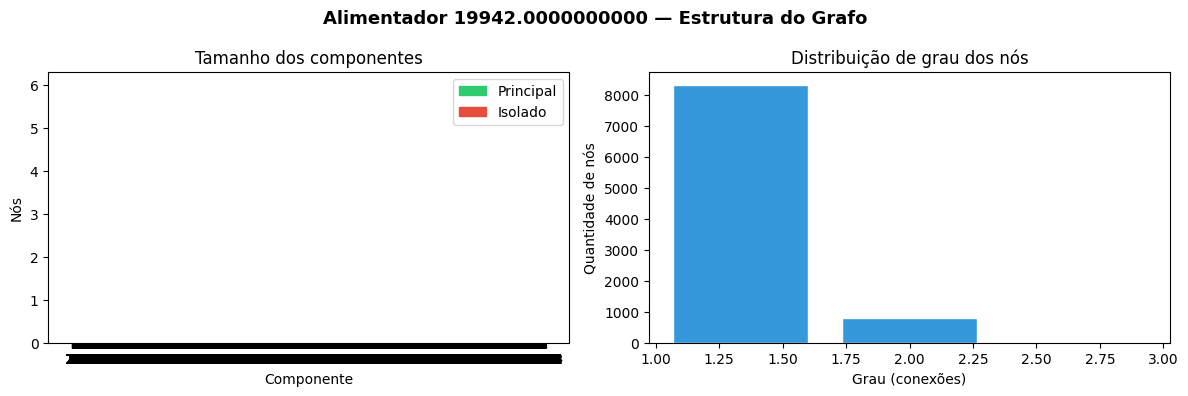

Componente principal : 6 nós
Ilhas detectadas     : 4153 (total de 9137 nós isolados)


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

componentes = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
tamanhos = [len(c) for c in componentes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Alimentador {ALIMENTADOR_ID} — Estrutura do Grafo', fontsize=13, fontweight='bold')

# --- Gráfico 1: tamanho dos componentes ---
cores_bar = ['#2ecc71'] + ['#e74c3c'] * (len(tamanhos) - 1)
axes[0].bar(range(1, len(tamanhos) + 1), tamanhos, color=cores_bar, edgecolor='white')
axes[0].set_title('Tamanho dos componentes')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Nós')
axes[0].set_xticks(range(1, len(tamanhos) + 1))
legenda = [
    mpatches.Patch(color='#2ecc71', label='Principal'),
    mpatches.Patch(color='#e74c3c', label='Isolado'),
]
axes[0].legend(handles=legenda)

# --- Gráfico 2: distribuição de graus dos nós ---
graus = [d for _, d in G.degree()]
axes[1].hist(graus, bins=max(graus) if graus else 1, color='#3498db', edgecolor='white', rwidth=0.8)
axes[1].set_title('Distribuição de grau dos nós')
axes[1].set_xlabel('Grau (conexões)')
axes[1].set_ylabel('Quantidade de nós')

plt.tight_layout()
plt.show()

print(f'Componente principal : {tamanhos[0]} nós')
if len(tamanhos) > 1:
    print(f'Ilhas detectadas     : {len(tamanhos) - 1} (total de {sum(tamanhos[1:])} nós isolados)')

## 5. Analise em lote - multiplos alimentadores

O app de producao processa todos os alimentadores em sequencia e gera um relatorio.
Aqui fazemos o mesmo para os primeiros N alimentadores.

In [7]:
TOP_N = 10
alimentadores_lista = df_alimentadores['AL_ID'].head(TOP_N).tolist()

# Carregar todos de uma vez (mais eficiente que N queries separadas)
al_ids_str = ', '.join(str(int(a)) for a in alimentadores_lista)
df_todos = read_sql_to_dataframe(f"""
    SELECT
        T.MSLINK,
        T.NO_ID_DE,
        T.NO_ID_PA,
        T.TRC_COMPRIMENTO,
        I.AL_ID
    FROM EQTLINFO_RAW.MAPA_PA.TRECHO_DE_REDE T
    INNER JOIN EQTLINFO_RAW.MAPA_PA.INSTALACAO I
        ON T.MSLINK = I.MSLINK_TR
    WHERE I.AL_ID IN ({al_ids_str})
""")

print(f'Total de trechos carregados: {len(df_todos)}')
print(f'Processando {TOP_N} alimentadores...\n')

relatorio = []
for al_id in alimentadores_lista:
    df_al = df_todos[df_todos['AL_ID'] == al_id]
    if df_al.empty:
        continue
    G_al = construir_grafo(df_al)
    r = analisar_conectividade(G_al)
    relatorio.append({
        'AL_ID': al_id,
        'TRECHOS': len(df_al),
        'NOS': r['nos'],
        'COMPONENTES': r['componentes'],
        'STATUS': 'OK' if r['conexo'] else 'PROBLEMA',
        'NOS_ISOLADOS': sum(len(c) for c in r['isolados']),
    })

df_relatorio = pd.DataFrame(relatorio)
print(df_relatorio.to_string(index=False))
print(f'\nOK: {(df_relatorio["STATUS"]=="OK").sum()} | PROBLEMA: {(df_relatorio["STATUS"]=="PROBLEMA").sum()}')

INFO: Conectando ao Snowflake (account=khb56279.us-east-1, database=EQTLINFO_HML, schema=EQTL_MA)...


INFO: Snowflake Connector for Python Version: 4.3.0, Python Version: 3.12.3, Platform: Linux-6.17.0-19-generic-x86_64-with-glibc2.39


INFO: Connecting to GLOBAL Snowflake domain


INFO: Conexão estabelecida com sucesso.


INFO: Conexão encerrada.


Total de trechos carregados: 40119
Processando 10 alimentadores...



           AL_ID  TRECHOS  NOS  COMPONENTES   STATUS  NOS_ISOLADOS
19942.0000000000     5774 9143         4154 PROBLEMA          9137
18345.0000000000     4920 8217         3828 PROBLEMA          8211
15882.0000000000     3947 6608         3104 PROBLEMA          6603
16643.0000000000     3897 5764         2631 PROBLEMA          5759
16644.0000000000     3877 6045         2767 PROBLEMA          6039
24502.0000000000     3785 6042         2806 PROBLEMA          6037
16684.0000000000     3723 5910         2707 PROBLEMA          5905
16683.0000000000     3409 5341         2433 PROBLEMA          5335
16724.0000000000     3402 5269         2351 PROBLEMA          5263
16062.0000000000     3385 5627         2628 PROBLEMA          5622

OK: 0 | PROBLEMA: 10


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


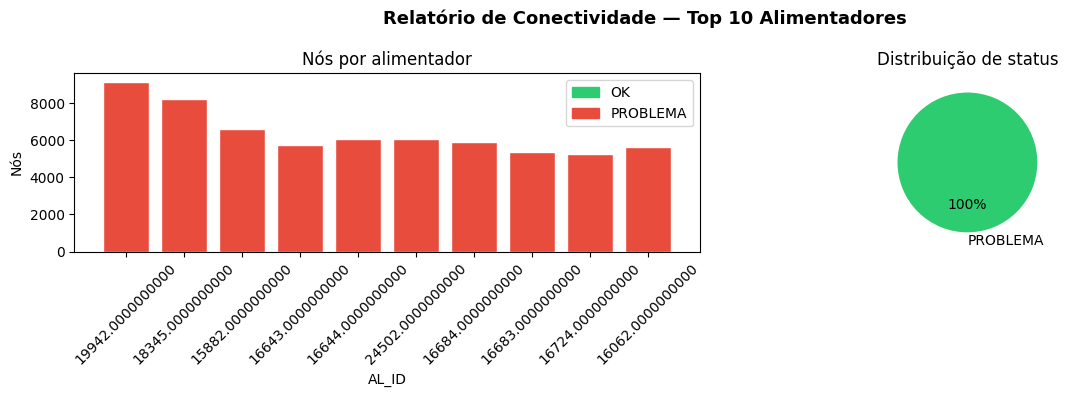

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Relatório de Conectividade — Top {TOP_N} Alimentadores', fontsize=13, fontweight='bold')

cores_status = df_relatorio['STATUS'].map({'OK': '#2ecc71', 'PROBLEMA': '#e74c3c'})

# --- Gráfico 1: nós por alimentador, colorido por status ---
axes[0].bar(
    df_relatorio['AL_ID'].astype(str),
    df_relatorio['NOS'],
    color=cores_status,
    edgecolor='white',
)
axes[0].set_title('Nós por alimentador')
axes[0].set_xlabel('AL_ID')
axes[0].set_ylabel('Nós')
axes[0].tick_params(axis='x', rotation=45)
legenda = [
    mpatches.Patch(color='#2ecc71', label='OK'),
    mpatches.Patch(color='#e74c3c', label='PROBLEMA'),
]
axes[0].legend(handles=legenda)

# --- Gráfico 2: pizza OK vs PROBLEMA ---
contagem = df_relatorio['STATUS'].value_counts()
axes[1].pie(
    contagem.values,
    labels=contagem.index,
    colors=['#2ecc71', '#e74c3c'][:len(contagem)],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[1].set_title('Distribuição de status')

plt.tight_layout()
plt.show()

## 6. Visualizacao com Folium

O app de producao usa WKT (coluna `SHAPE`) para desenhar trechos no mapa.
Aqui usamos lat/lon dos consumidores como proxy das coordenadas dos nos de rede --
a mesma logica de `_criar_mapa()` e `_adicionar_fase_ao_mapa()` do app.

In [9]:
nos_ids = pd.concat([
    df_trechos['NO_ID_DE'].dropna(),
    df_trechos['NO_ID_PA'].dropna(),
]).unique()

df_nos_latlon = pd.DataFrame(columns=['NO_ID', 'LAT', 'LON'])

if len(nos_ids) == 0:
    print('Sem nós para resolver.')
else:
    nos_str = ', '.join(str(int(n)) for n in nos_ids[:500])

    # Passo 1: NO_ID -> CR_NUMERO (numérico) via MAPA_PA.CONSUMIDOR
    df_no_cr = read_sql_to_dataframe(f"""
        SELECT DISTINCT NO_ID, CR_NUMERO
        FROM EQTLINFO_RAW.MAPA_PA.CONSUMIDOR
        WHERE NO_ID IN ({nos_str})
        LIMIT 500
    """)
    print(f'Nós resolvidos via MAPA_PA.CONSUMIDOR: {len(df_no_cr)}')

    if not df_no_cr.empty:
        # CR_NUMERO em MAPA_PA é numérico; em TAB_CADASTRO é string com zero-padding
        # Normalize: converte para inteiro -> string para montar o IN
        df_no_cr['CR_NUMERO_INT'] = pd.to_numeric(df_no_cr['CR_NUMERO'], errors='coerce').astype('Int64')
        crs_validos = df_no_cr['CR_NUMERO_INT'].dropna().head(200).tolist()
        crs_str = ', '.join(str(c) for c in crs_validos)

        # Passo 2: CR_NUMERO -> lat/lon via TAB_CADASTRO (usando TRY_CAST para garantir)
        df_coords = read_sql_to_dataframe(f"""
            SELECT
                TRY_CAST(INSTALACAO AS INTEGER)    AS CR_NUMERO_INT,
                TRY_CAST(LATITUDE   AS FLOAT)      AS LAT,
                TRY_CAST(LONGITUDE  AS FLOAT)      AS LON
            FROM EQTLINFO_PRD.EQTL_PA.TAB_CADASTRO
            WHERE TRY_CAST(INSTALACAO AS INTEGER) IN ({crs_str})
              AND LATITUDE  IS NOT NULL
              AND LONGITUDE IS NOT NULL
        """)

        # Juntar NO_ID -> CR_NUMERO_INT -> lat/lon
        df_nos_latlon = (
            df_no_cr[['NO_ID', 'CR_NUMERO_INT']]
            .merge(df_coords[['CR_NUMERO_INT', 'LAT', 'LON']], on='CR_NUMERO_INT', how='inner')
            .drop_duplicates('NO_ID')
        )
        print(f'Nós com coordenadas lat/lon: {len(df_nos_latlon)}')
    else:
        print('Sem vínculo na MAPA_PA.CONSUMIDOR para os nós deste alimentador.')

INFO: Conectando ao Snowflake (account=khb56279.us-east-1, database=EQTLINFO_HML, schema=EQTL_MA)...


INFO: Snowflake Connector for Python Version: 4.3.0, Python Version: 3.12.3, Platform: Linux-6.17.0-19-generic-x86_64-with-glibc2.39


INFO: Connecting to GLOBAL Snowflake domain


INFO: Conexão estabelecida com sucesso.


INFO: Conexão encerrada.


...

INFO: Connecting to GLOBAL Snowflake domain


Nós resolvidos via MAPA_PA.CONSUMIDOR: 32


INFO: Conexão estabelecida com sucesso.


INFO: Conexão encerrada.


Nós com coordenadas lat/lon: 28


In [10]:
def gerar_mapa_conectividade(G, df_coords, alimentador_id, resultado):
    """
    Reproduz _criar_mapa() + _adicionar_fase_ao_mapa() do app de producao.
    Verde = componente principal | Vermelho/laranja = nos isolados.
    """
    coord_map = {
        row['NO_ID']: (row['LAT'], row['LON'])
        for _, row in df_coords.iterrows()
        if pd.notna(row['LAT']) and pd.notna(row['LON'])
    }
    if not coord_map:
        print('Sem coordenadas para gerar o mapa.')
        return None

    lats = [c[0] for c in coord_map.values()]
    lons = [c[1] for c in coord_map.values()]
    m = folium.Map(location=[np.mean(lats), np.mean(lons)], zoom_start=14, tiles='OpenStreetMap')

    componentes = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
    cores = ['#008800', '#CC0000', '#FF6600', '#9900CC', '#0044AA'] + ['#CC0000'] * 50

    nos_group   = folium.FeatureGroup(name='Nos', show=True)
    arestas_group = folium.FeatureGroup(name='Arestas', show=True)

    for idx, comp in enumerate(componentes):
        cor   = cores[min(idx, len(cores) - 1)]
        label = 'Principal' if idx == 0 else f'Isolado {idx}'

        for no_id in comp:
            if no_id in coord_map:
                lat, lon = coord_map[no_id]
                folium.CircleMarker(
                    location=[lat, lon], radius=5,
                    color='#000', fill_color=cor, fill_opacity=0.9, weight=1,
                    popup=f'No: {no_id}<br>Componente: {label}',
                    tooltip=f'{label}: {no_id}',
                ).add_to(nos_group)

        for origem, destino in G.edges():
            if origem in comp and destino in comp:
                if origem in coord_map and destino in coord_map:
                    o = coord_map[origem]
                    d = coord_map[destino]
                    folium.PolyLine(
                        locations=[[o[0], o[1]], [d[0], d[1]]],
                        color=cor, weight=3, opacity=0.7,
                        tooltip=f'{origem} -> {destino}',
                    ).add_to(arestas_group)

    nos_group.add_to(m)
    arestas_group.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)

    status_str = 'Conexo' if resultado['conexo'] else f'PROBLEMA: {resultado["componentes"]} componentes'
    titulo = (
        f'<h3 align="center"><b>Alimentador {alimentador_id} - Diagnostico de Conectividade</b></h3>'
        f'<p align="center">Verde = componente principal | Vermelho = nos isolados<br>'
        f'<b>Status: {status_str}</b></p>'
    )
    m.get_root().html.add_child(folium.Element(titulo))
    return m


mapa = gerar_mapa_conectividade(G, df_nos_latlon, ALIMENTADOR_ID, resultado)
if mapa:
    mapa_path = project_root / f'modulo5_snowflake_qualidade/mapa_alimentador_{int(ALIMENTADOR_ID)}.html'
    mapa.save(str(mapa_path))
    print(f'Mapa salvo: {mapa_path.name}')
    display(mapa)

Mapa salvo: mapa_alimentador_19942.html


## 7. Comparacao: notebook vs. app de producao

| Etapa | App Streamlit (producao) | Este notebook |
|-------|--------------------------|---------------|
| Fonte de dados | Upload CSV (exportado do Snowflake) | Query direta no Snowflake |
| Geometria | WKT coluna `SHAPE` (UTM 29192) | Lat/lon via join com cadastro |
| Analise de fase | Por `TB_CDF_ID` (A/B/C/ABC) | Topologica (grafo unificado) |
| Grafo | `nx.DiGraph` por fase | `nx.DiGraph` unificado |
| Deteccao de problema | `weakly_connected_components > 1` | Mesmo algoritmo |
| Mapa | Folium - cores por fase | Folium - cores por componente |
| Interface | Streamlit UI | Jupyter notebook |

**O algoritmo central e identico.** A diferenca esta na fonte de dados e camada visual.

In [11]:
# Relatorio final -- mesmo formato do app de producao
problemas = df_relatorio[df_relatorio['STATUS'] == 'PROBLEMA']

print('RELATORIO DE CONECTIVIDADE')
print('=' * 50)
print(f'Alimentadores analisados : {len(df_relatorio)}')
print(f'Conexos (OK)             : {(df_relatorio["STATUS"] == "OK").sum()}')
print(f'Com problema             : {len(problemas)}')
print()

if not problemas.empty:
    print('Alimentadores com problema:')
    for _, row in problemas.iterrows():
        print(
            f'  AL_ID={row["AL_ID"]:>10} | '
            f'{row["NOS"]:>4} nos | '
            f'{row["COMPONENTES"]} componentes | '
            f'{row["NOS_ISOLADOS"]} nos isolados'
        )
else:
    print('  Todos os alimentadores analisados estao conexos.')

RELATORIO DE CONECTIVIDADE
Alimentadores analisados : 10
Conexos (OK)             : 0
Com problema             : 10

Alimentadores com problema:
  AL_ID=19942.0000000000 | 9143 nos | 4154 componentes | 9137 nos isolados
  AL_ID=18345.0000000000 | 8217 nos | 3828 componentes | 8211 nos isolados
  AL_ID=15882.0000000000 | 6608 nos | 3104 componentes | 6603 nos isolados
  AL_ID=16643.0000000000 | 5764 nos | 2631 componentes | 5759 nos isolados
  AL_ID=16644.0000000000 | 6045 nos | 2767 componentes | 6039 nos isolados
  AL_ID=24502.0000000000 | 6042 nos | 2806 componentes | 6037 nos isolados
  AL_ID=16684.0000000000 | 5910 nos | 2707 componentes | 5905 nos isolados
  AL_ID=16683.0000000000 | 5341 nos | 2433 componentes | 5335 nos isolados
  AL_ID=16724.0000000000 | 5269 nos | 2351 componentes | 5263 nos isolados
  AL_ID=16062.0000000000 | 5627 nos | 2628 componentes | 5622 nos isolados
